In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

In [4]:
facilities_data = pd.read_csv("..\\Data\\New_York_City_Facilities_Database\\facilities_24v2.csv")
fac_filtered_cols = facilities_data[["CITY","FACTYPE","FACSUBGRP","FACDOMAIN","BORO"]]

<positron-console-cell-5>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



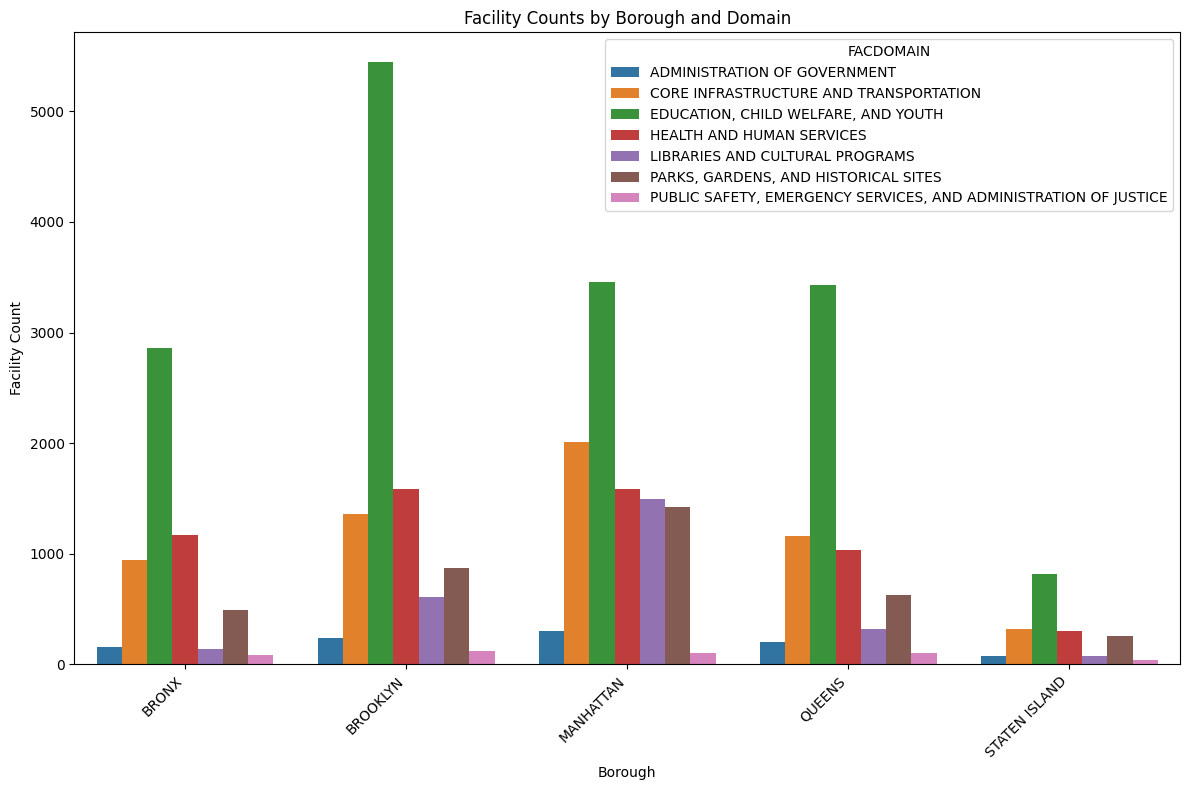

In [5]:
facility_type_by_boro = fac_filtered_cols.groupby(['BORO', 'FACDOMAIN']).size().reset_index(name='Facility Count')

plt.figure(figsize=(12, 8))

sns.barplot(x='BORO', y='Facility Count', hue='FACDOMAIN', data=facility_type_by_boro, ci=None)

plt.xticks(rotation=45, ha='right')
plt.title('Facility Counts by Borough and Domain')
plt.xlabel('Borough')
plt.ylabel('Facility Count')

plt.tight_layout()
plt.show()

<positron-console-cell-6>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



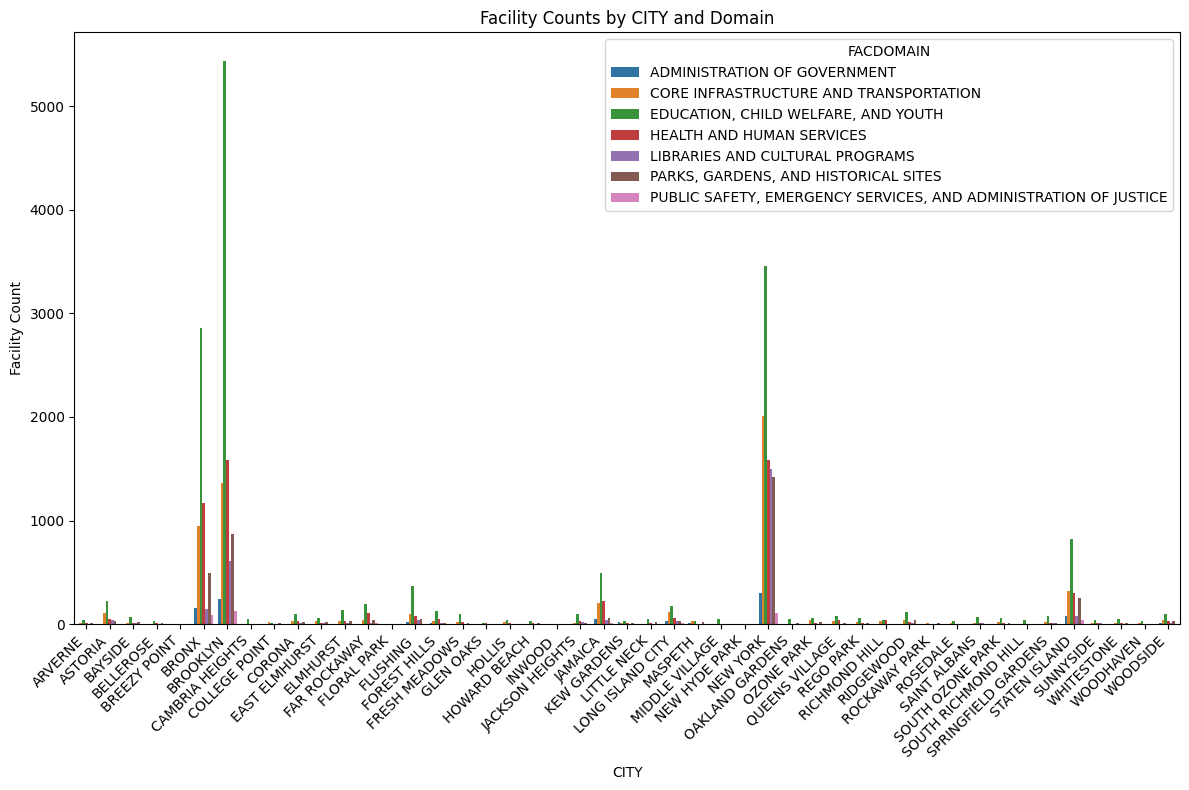

In [6]:
facility_type_by_city = fac_filtered_cols.groupby(['CITY', 'FACDOMAIN']).size().reset_index(name='Facility Count')

plt.figure(figsize=(12, 8))

sns.barplot(x='CITY', y='Facility Count', hue='FACDOMAIN', data=facility_type_by_city, ci=None)

plt.xticks(rotation=45, ha='right')
plt.title('Facility Counts by CITY and Domain')
plt.xlabel('CITY')
plt.ylabel('Facility Count')

plt.tight_layout()
plt.show()

For the purposes of airbnb I think the most interesting domains are core infrastructure and transportation, Libraries and cultural programs, parks gardens and historical sights.

In [7]:
domains_of_interest = fac_filtered_cols[fac_filtered_cols['FACDOMAIN'].isin(['LIBRARIES AND CULTURAL PROGRAMS', 'CORE INFRASTRUCTURE AND TRANSPORTATION','PARKS, GARDENS, AND HISTORICAL SITES'])]


<positron-console-cell-8>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



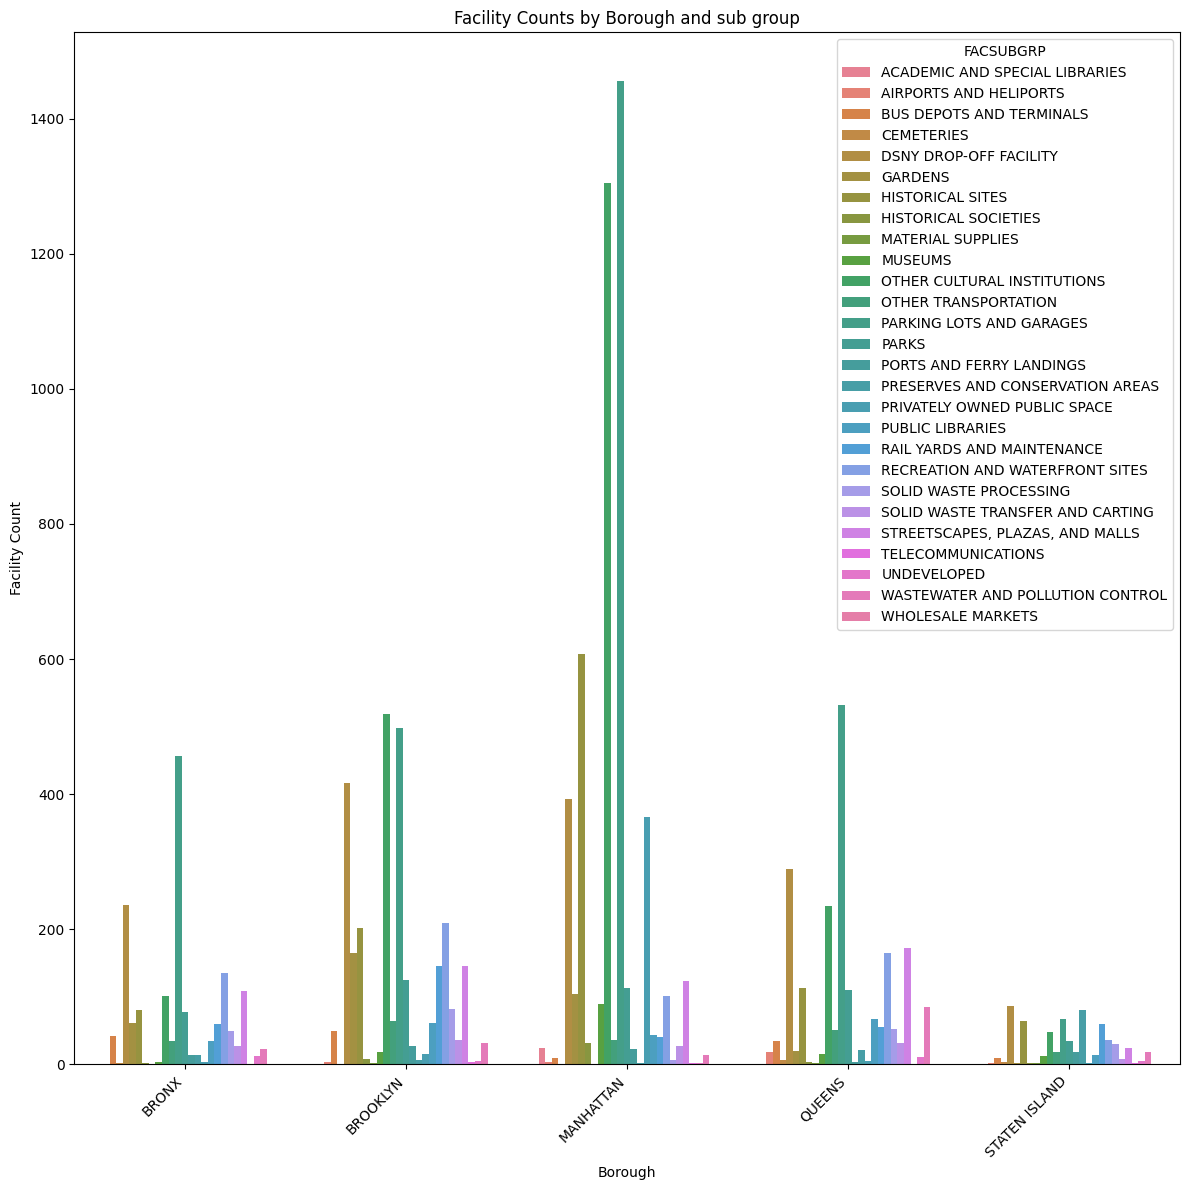

In [8]:
interesting_domains_boro = domains_of_interest.groupby(['BORO', 'FACSUBGRP']).size().reset_index(name='Facility Count')

plt.figure(figsize=(12, 12))

sns.barplot(x='BORO', y='Facility Count', hue='FACSUBGRP', data=interesting_domains_boro, ci=None)

plt.xticks(rotation=45, ha='right')
plt.title('Facility Counts by Borough and sub group')
plt.xlabel('Borough')
plt.ylabel('Facility Count')

plt.tight_layout()
plt.show()

<positron-console-cell-9>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



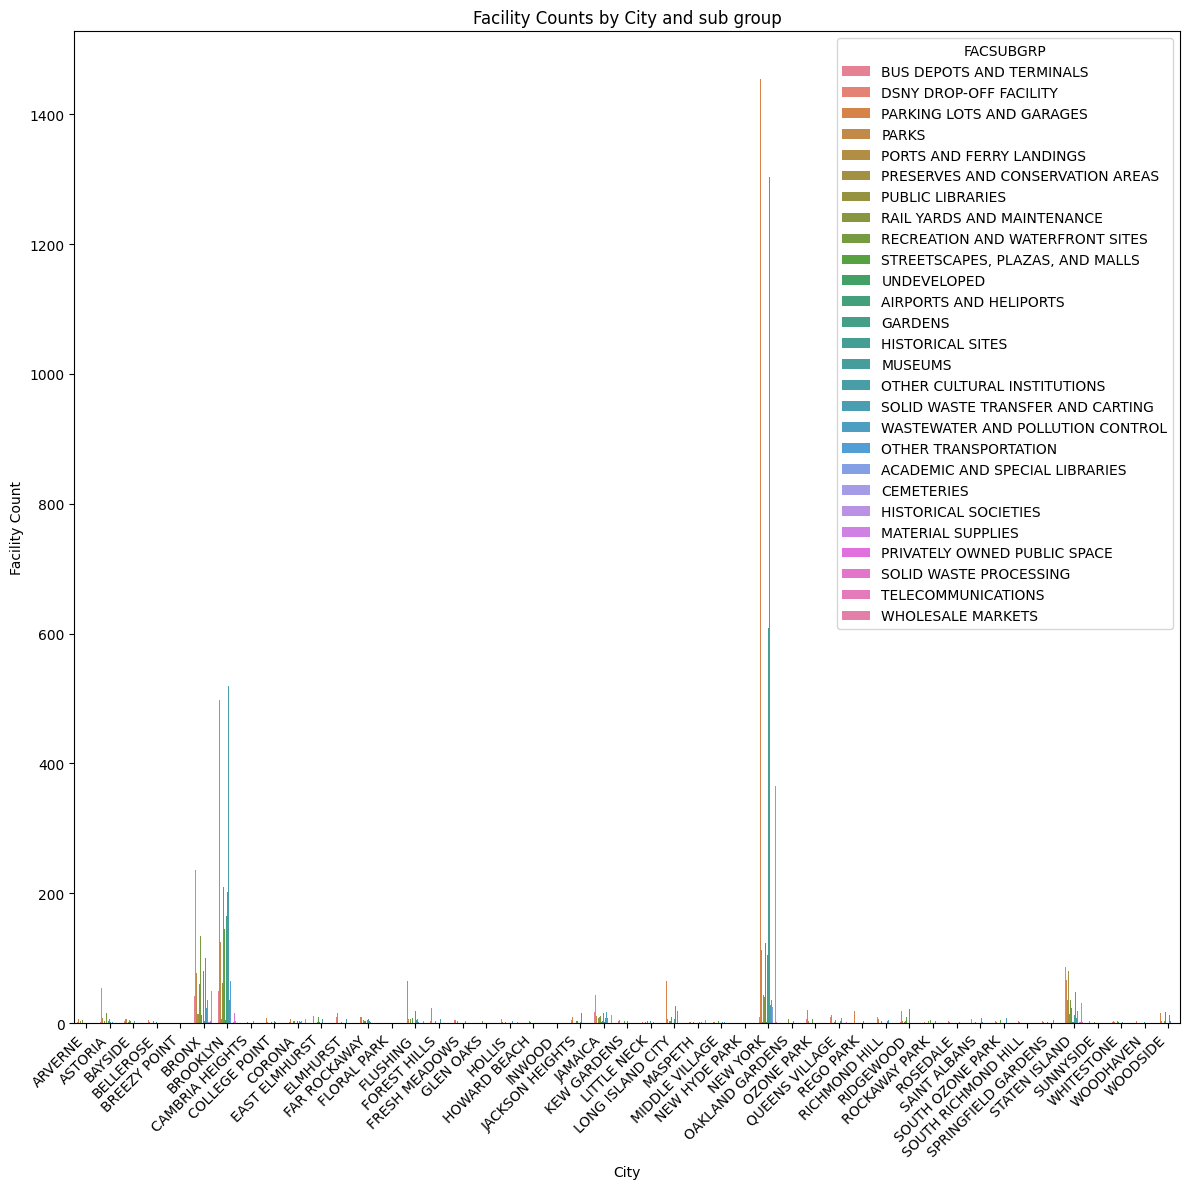

In [9]:
interesting_domains_city = domains_of_interest.groupby(['CITY', 'FACSUBGRP']).size().reset_index(name='Facility Count')

plt.figure(figsize=(12, 12))

sns.barplot(x='CITY', y='Facility Count', hue='FACSUBGRP', data=interesting_domains_city, ci=None)

plt.xticks(rotation=45, ha='right')
plt.title('Facility Counts by City and sub group')
plt.xlabel('City')
plt.ylabel('Facility Count')

plt.tight_layout()
plt.show()

# Assign airbnb neighborhoods to facilities

In [10]:
neighborhoods = gpd.read_file('..\\Data\\Airbnb_NY_City_04112024\\neighbourhoods.geojson')

geometry = [Point(lon, lat) for lon, lat in zip(facilities_data['LONGITUDE'], facilities_data['LATITUDE'])]
gdf_data = gpd.GeoDataFrame(facilities_data, geometry=geometry)

gdf_data.set_crs(neighborhoods.crs, allow_override=True, inplace=True)

def get_neighborhood(row):
    point = row['geometry']
    for _, neighborhood in neighborhoods.iterrows():
        if neighborhood['geometry'].contains(point):
            return neighborhood['neighbourhood']
    return None

gdf_data['neighborhood'] = gdf_data.apply(get_neighborhood, axis=1)


neighborhood_map = gdf_data[['FACNAME','neighborhood']]

<positron-console-cell-11>:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



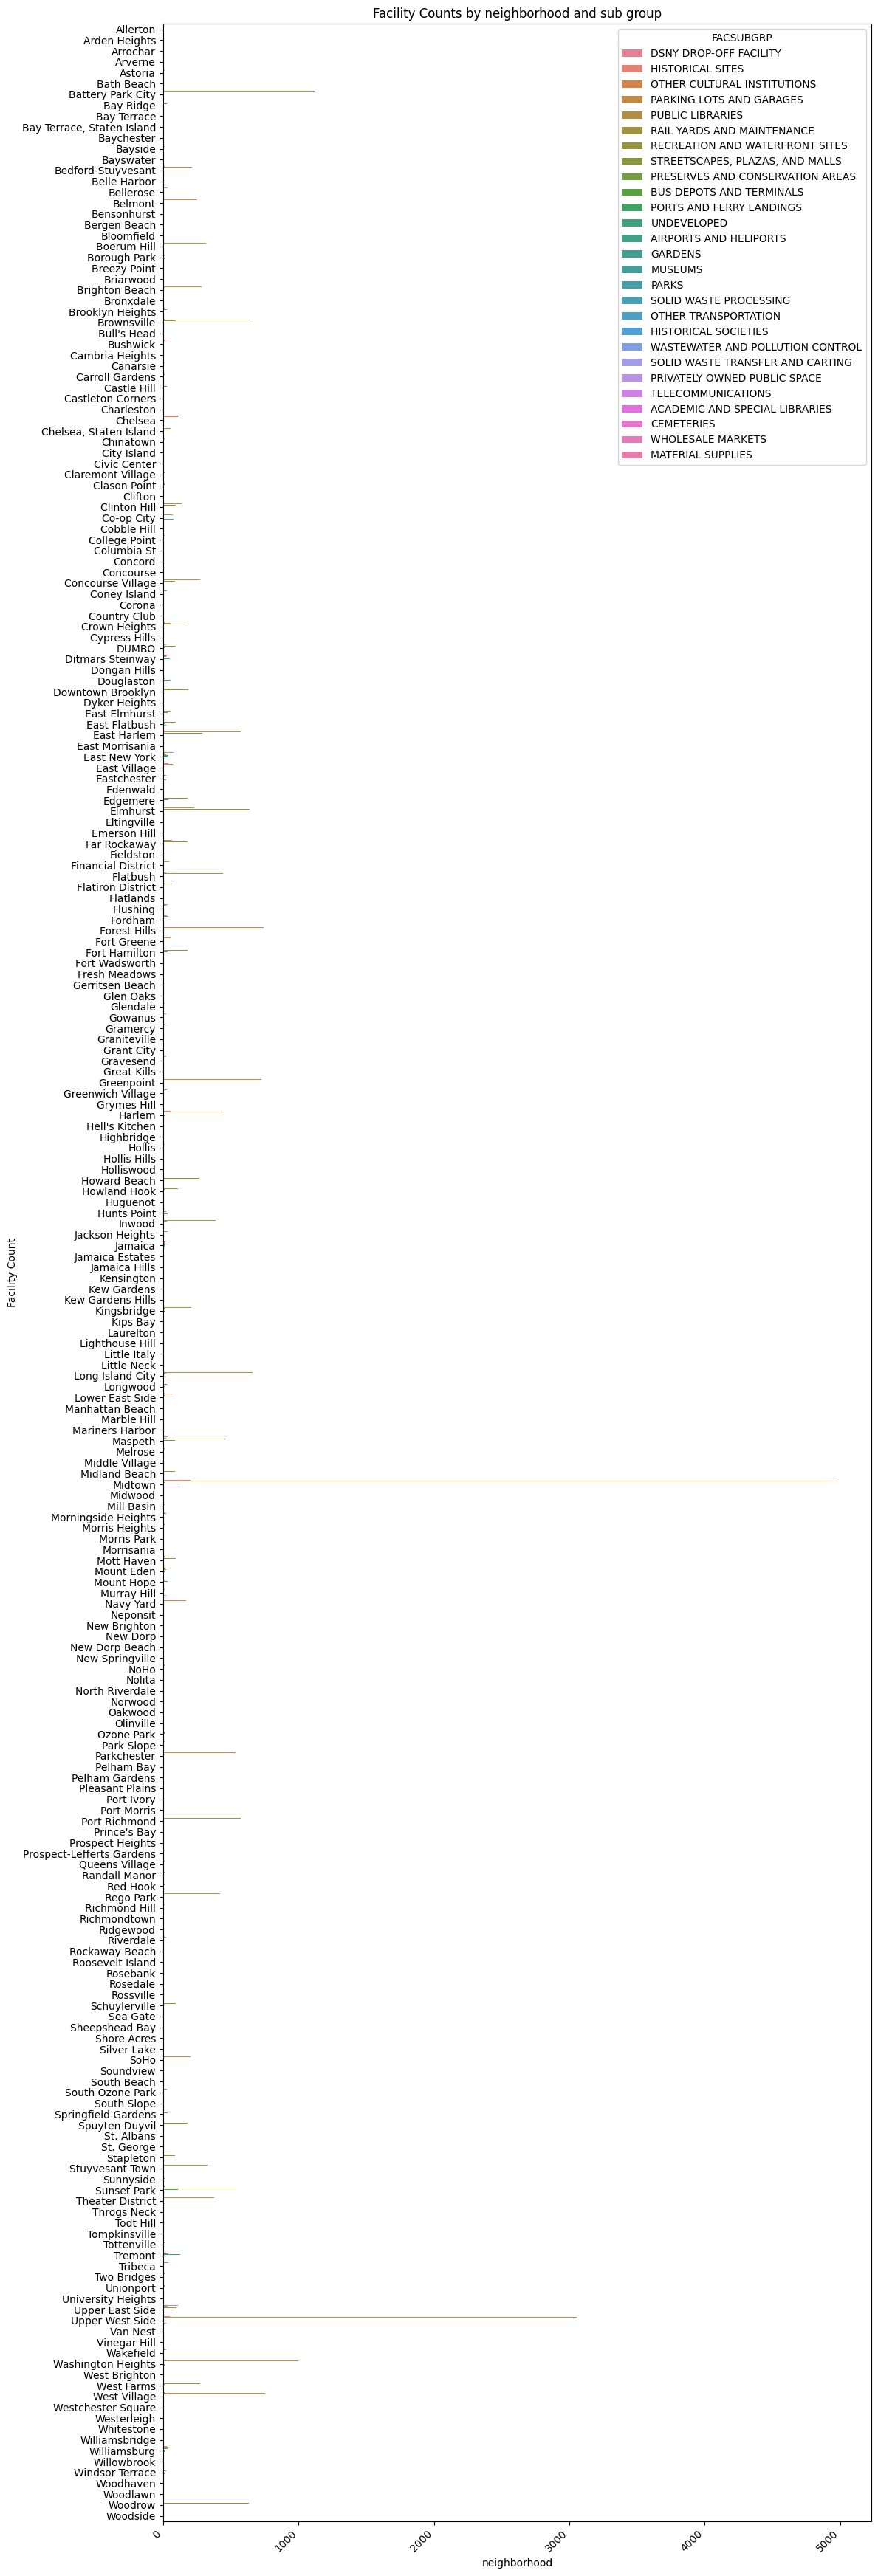

In [11]:
merged_data = pd.merge(facilities_data,neighborhood_map,on='FACNAME')
fac_filtered_cols = merged_data[["FACTYPE","FACSUBGRP","FACDOMAIN","neighborhood"]]
domains_of_interest = fac_filtered_cols[fac_filtered_cols['FACDOMAIN'].isin(['LIBRARIES AND CULTURAL PROGRAMS', 'CORE INFRASTRUCTURE AND TRANSPORTATION','PARKS, GARDENS, AND HISTORICAL SITES'])]


interesting_domains_airbnb_neighhorhood = domains_of_interest.groupby(['neighborhood', 'FACSUBGRP']).size().reset_index(name='Facility Count')

plt.figure(figsize=(12, 35))

sns.barplot(y='neighborhood', x='Facility Count', hue='FACSUBGRP', data=interesting_domains_airbnb_neighhorhood, ci=None)

plt.xticks(rotation=45, ha='right')
plt.title('Facility Counts by neighborhood and sub group')
plt.xlabel('neighborhood')
plt.ylabel('Facility Count')

plt.tight_layout()
plt.show()

### further filtering of facilities

In [12]:
domains_of_interest['FACSUBGRP'].unique()

array(['OTHER CULTURAL INSTITUTIONS', 'BUS DEPOTS AND TERMINALS', 'RECREATION AND WATERFRONT SITES', 'PARKING LOTS AND GARAGES', 'STREETSCAPES, PLAZAS, AND MALLS', 'RAIL YARDS AND MAINTENANCE', 'DSNY DROP-OFF FACILITY', 'GARDENS', 'HISTORICAL SITES', 'MUSEUMS', 'WASTEWATER AND POLLUTION CONTROL',
       'PUBLIC LIBRARIES', 'PRESERVES AND CONSERVATION AREAS', 'OTHER TRANSPORTATION', 'PARKS', 'TELECOMMUNICATIONS', 'SOLID WASTE TRANSFER AND CARTING', 'ACADEMIC AND SPECIAL LIBRARIES', 'PORTS AND FERRY LANDINGS', 'SOLID WASTE PROCESSING', 'UNDEVELOPED', 'CEMETERIES', 'HISTORICAL SOCIETIES',
       'AIRPORTS AND HELIPORTS', 'MATERIAL SUPPLIES', 'WHOLESALE MARKETS', 'PRIVATELY OWNED PUBLIC SPACE'], dtype=object)

In [13]:
tokeep = ['OTHER CULTURAL INSTITUTIONS', 'BUS DEPOTS AND TERMINALS', 'RECREATION AND WATERFRONT SITES',
       'PARKING LOTS AND GARAGES', 'STREETSCAPES, PLAZAS, AND MALLS',
       'GARDENS', 'HISTORICAL SITES', 'MUSEUMS',
       'PUBLIC LIBRARIES', 'PRESERVES AND CONSERVATION AREAS', 'OTHER TRANSPORTATION', 'PARKS',
       'ACADEMIC AND SPECIAL LIBRARIES', 'PORTS AND FERRY LANDINGS',
       'CEMETERIES', 'HISTORICAL SOCIETIES', 'AIRPORTS AND HELIPORTS',
       'WHOLESALE MARKETS', 'PRIVATELY OWNED PUBLIC SPACE']
domains_of_interest = domains_of_interest[domains_of_interest['FACSUBGRP'].isin(tokeep)]


In [14]:
domains_of_interest['FACTYPE'].unique()

array(['HUMANITIES', 'SCHOOL BUS DEPOT', 'PLAYGROUND', 'COMMERCIAL PARKING LOT', 'PEDESTRIAN PLAZA', 'THEATER', 'LITERATURE', 'COMMERCIAL GARAGE', 'GARDEN', 'STATE HISTORIC PLACE', 'MULTI-DISCIPLINE, NON-PERFORM', 'TRIANGLE/PLAZA', 'MUSIC', 'COMMERCIAL GARAGE AND PARKING LOT',
       'MULTI-DISCIPL, PERF & NON-PERF', 'TOW TRUCK COMPANY', 'MUSEUM', 'PUBLIC LIBRARY', 'MULTI-DISCIPLINE, PERFORMING', 'NATURE AREA', 'TRANSPORTATION FACILITY', 'RECREATIONAL FIELD/COURTS', 'FILM/VIDEO/AUDIO', 'HISTORIC HOUSE PARK', 'DANCE', 'COMMUNITY PARK', 'NEIGHBORHOOD PARK',
       'PRIVATE MUSEUMS AND SITES', 'VISUAL ARTS', 'PUBLIC MUSEUMS AND SITES', 'NEW MEDIA', 'JOINTLY OPERATED PLAYGROUND', 'SPECIAL LIBRARIES', 'PORT OR MARINE TERMINAL', 'STATE FOREST', 'PHOTOGRAPHY', 'PUBLIC PARKING', 'STRIP', 'FOLK ARTS', 'MAINTENANCE, MANAGEMENT, AND OPERATIONS', 'UNIQUE AREA',
       'MALL', 'MUNICIPAL PARKING - OUTDOOR', 'WATERFRONT FACILITY', 'BRIDGE HOUSE', 'CITY-STATE PARK', 'OPERATIONS', 'MUNICIPAL PARKING -

In [15]:
tokeep = ['HUMANITIES', 'PLAYGROUND', 'COMMERCIAL PARKING LOT', 'PEDESTRIAN PLAZA', 'THEATER',
       'LITERATURE', 'COMMERCIAL GARAGE', 'GARDEN', 'STATE HISTORIC PLACE', 'MULTI-DISCIPLINE, NON-PERFORM',
       'TRIANGLE/PLAZA', 'MUSIC', 'COMMERCIAL GARAGE AND PARKING LOT', 'MULTI-DISCIPL, PERF & NON-PERF',
       'MUSEUM', 'PUBLIC LIBRARY', 'MULTI-DISCIPLINE, PERFORMING', 'NATURE AREA',
       'RECREATIONAL FIELD/COURTS', 'FILM/VIDEO/AUDIO', 'HISTORIC HOUSE PARK', 'DANCE',
       'COMMUNITY PARK', 'NEIGHBORHOOD PARK', 'PRIVATE MUSEUMS AND SITES', 'VISUAL ARTS', 'PUBLIC MUSEUMS AND SITES',
       'NEW MEDIA', 'JOINTLY OPERATED PLAYGROUND', 'SPECIAL LIBRARIES', 'PORT OR MARINE TERMINAL', 'STATE FOREST',
       'PHOTOGRAPHY', 'PUBLIC PARKING', 'STRIP', 'FOLK ARTS', 'UNIQUE AREA',
       'MALL', 'MUNICIPAL PARKING - OUTDOOR', 'WATERFRONT FACILITY', 'BRIDGE HOUSE', 'CITY-STATE PARK',
       'MUNICIPAL PARKING - INDOOR', 'CEMETERY', 'UNSPECIFIED DISCIPLINE', 'FLAGSHIP PARK', 'ARCHITECTURE/DESIGN',
       'HISTORICAL SOCIETIES', 'CASTLE CLINTON NATIONAL MONUMENT', 'BUS STATION', 'CRUISE TERMINAL', 'SCIENCE', 'HELIPORT',
       'BOTANICAL', 'BUILDINGS/INSTITUTIONS', 'MTA BUS DEPOT', 'MANAGED SITES', 'PIER - MARITIME USE', 'ZOO',
       'PARKWAY', 'MTA PARATRANSIT VEHICLE DEPOT', 'FERRY TERMINAL', 'MANNED TRANSPORTATION FACILITY', 'CRAFTS',
       'TIDAL WETLAND', 'STATE PARK', 'FERRY LANDING', 'PUBLIC PARK AND RIDE LOT', 'WATERFRONT TRANSPORTATION FACILITY',
       'PANYNJ BUS TERMINAL', 'AIRPORT', 'STATE PARK PRESERVE', 'NYCHA COMMUNITY CENTER - LIBRARY', 'ACADEMIC LIBRARIES',
       'NATURAL RESOURCE AREA', 'COMMERCIAL MARKET', 'HAMILTON GRANGE NATIONAL MEMORIAL',
       'THEODORE ROOSEVELT BIRTHPLACE NATIONAL HISTORIC SITE', 'FEDERAL HALL NATIONAL MEMORIAL',
       'STONEWALL NATIONAL MONUMENT', 'TRAILWAY', 'GENERAL GRANT NATIONAL MEMORIAL', 'GOVERNORS ISLAND NATIONAL MONUMENT',
       'AFRICAN BURIAL GROUND NATIONAL MONUMENT', 'PRIVATELY OWNED PUBLIC SPACE']
domains_of_interest = domains_of_interest[domains_of_interest['FACTYPE'].isin(tokeep)]

domains_of_interest.head()

,FACTYPE,FACSUBGRP,FACDOMAIN,neighborhood
5,HUMANITIES,OTHER CULTURAL INSTITUTIONS,LIBRARIES AND CULTURAL PROGRAMS,Chelsea
6,HUMANITIES,OTHER CULTURAL INSTITUTIONS,LIBRARIES AND CULTURAL PROGRAMS,Chelsea
13,PLAYGROUND,RECREATION AND WATERFRONT SITES,"PARKS, GARDENS, AND HISTORICAL SITES",Woodhaven
14,COMMERCIAL PARKING LOT,PARKING LOTS AND GARAGES,CORE INFRASTRUCTURE AND TRANSPORTATION,Hell's Kitchen
15,COMMERCIAL PARKING LOT,PARKING LOTS AND GARAGES,CORE INFRASTRUCTURE AND TRANSPORTATION,Hell's Kitchen


<Figure size 1200x700 with 0 Axes>

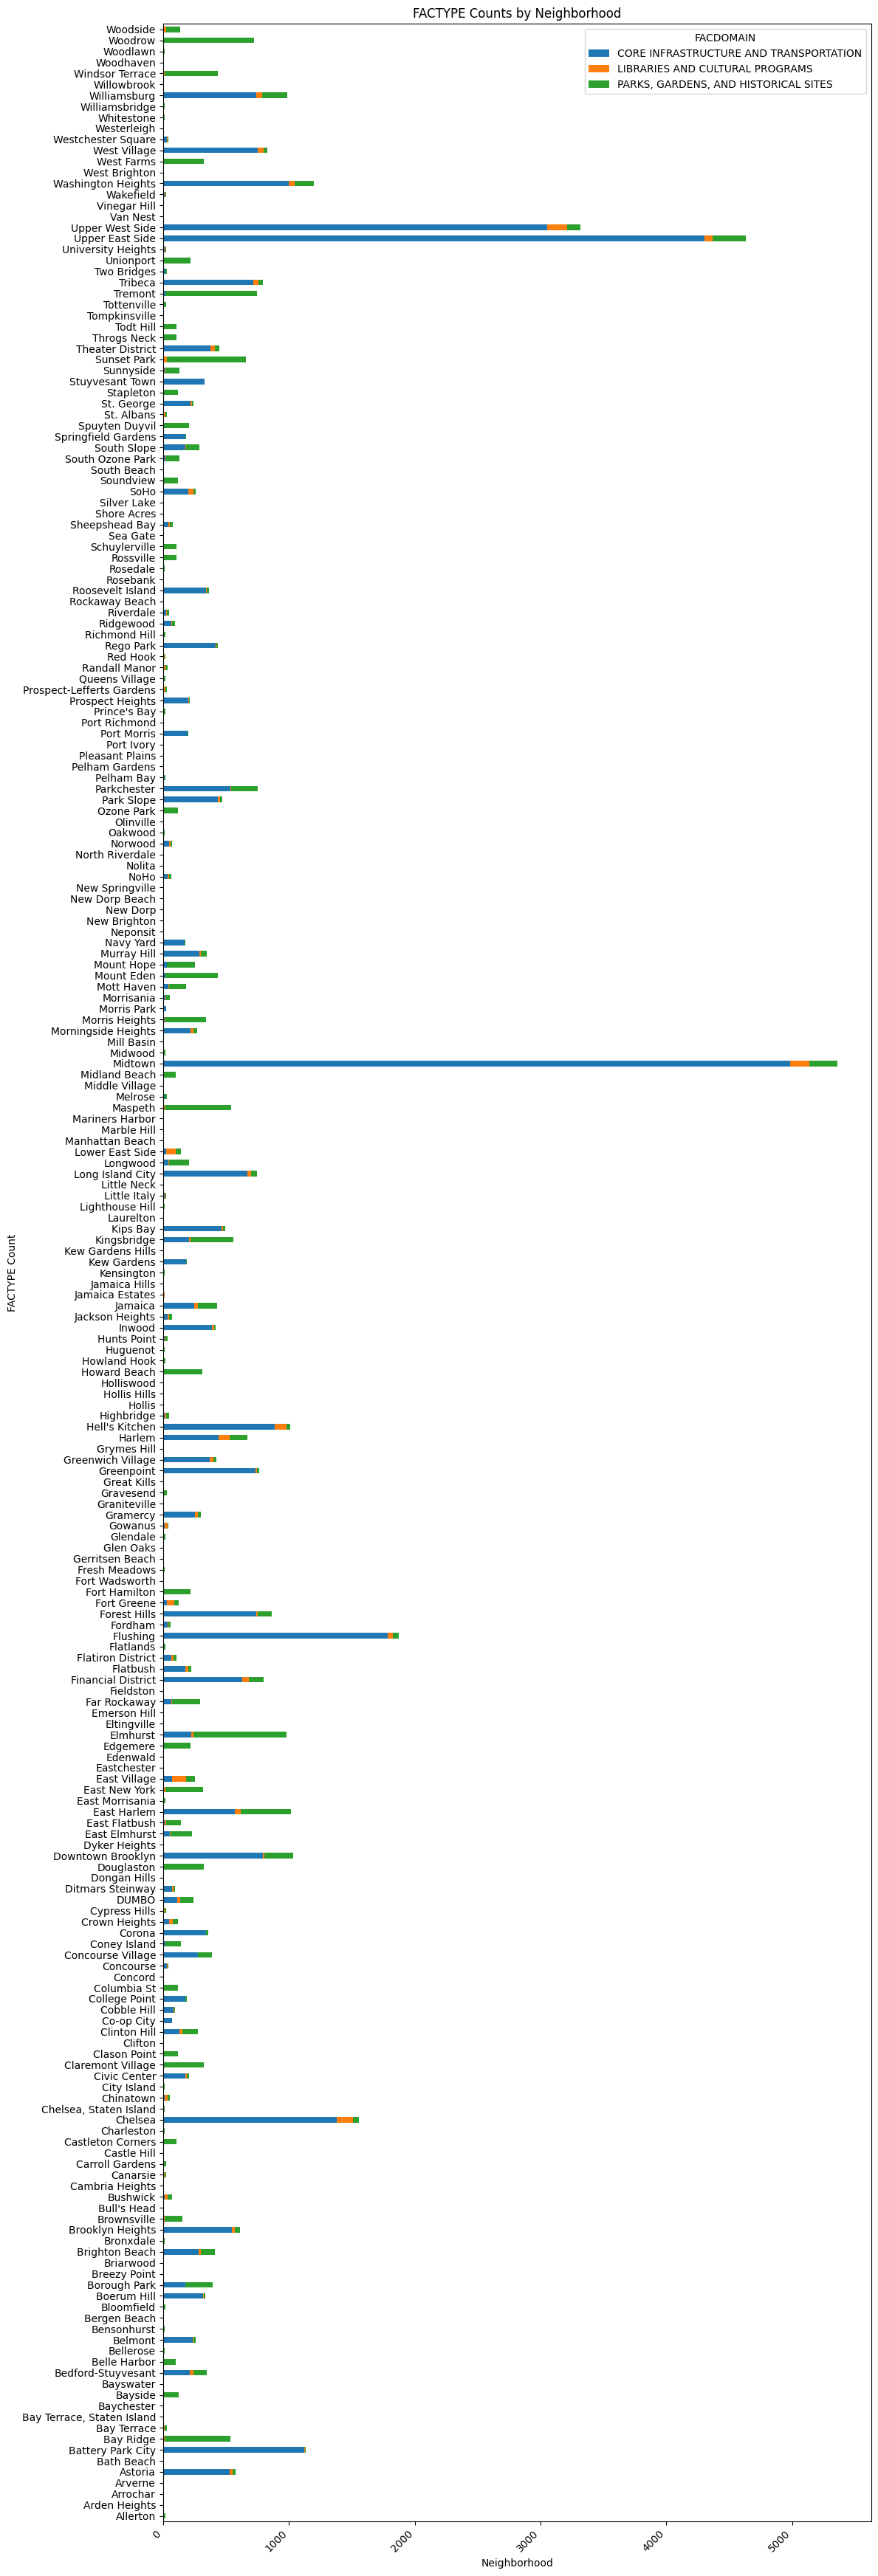

In [16]:
pivot_df = domains_of_interest.groupby(['neighborhood', 'FACDOMAIN']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))

pivot_df.plot(kind='barh', stacked=True, figsize=(12, 35))

plt.title('FACTYPE Counts by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('FACTYPE Count')
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()


## Create factype count df for clustering

In [17]:
import geopandas as gpd

gdf = gpd.read_file("..\\Data\\Airbnb_NY_City_04112024\\neighbourhoods.geojson")

print(gdf.crs)
gdf = gdf.to_crs(epsg=3395) 

gdf['area_meters_squared'] = gdf.geometry.area

print(gdf[['neighbourhood', 'area_meters_squared']])

EPSG:4326
          neighbourhood  area_meters_squared
0             Bayswater         4.073818e+05
1              Allerton         4.231216e+06
2           City Island         1.941968e+06
3      Ditmars Steinway         9.487752e+06
4            Ozone Park         8.383917e+06
..                  ...                  ...
228  Westchester Square         2.116559e+06
229         Westerleigh         2.941113e+06
230      Williamsbridge         3.655331e+06
231        Williamsburg         1.361841e+07
232         Willowbrook         1.468768e+06

[233 rows x 2 columns]


In [18]:
pivot_df_for_clustering = domains_of_interest.pivot_table(index='neighborhood', columns='FACTYPE', aggfunc='size', fill_value=0)
#pivot_df_for_clustering = 
#pivot_df_for_clustering.to_csv("factype_count_per_airbnb_neighborhood_normalized.csv")

In [19]:
merged_df = pd.merge(pivot_df_for_clustering, gdf[['neighbourhood', 'area_meters_squared']], left_on='neighborhood', right_on='neighbourhood', how='left')
numeric_columns = merged_df.select_dtypes(include=['number']).columns
for column in numeric_columns:
    merged_df[column] = merged_df[column] / merged_df['area_meters_squared']

merged_df = merged_df.drop(columns=['area_meters_squared'])
merged_df.to_csv("factype_count_per_airbnb_neighborhood_normalized.csv", index=False)
merged_df.head()

,ACADEMIC LIBRARIES,AFRICAN BURIAL GROUND NATIONAL MONUMENT,AIRPORT,ARCHITECTURE/DESIGN,BOTANICAL,BRIDGE HOUSE,BUILDINGS/INSTITUTIONS,BUS STATION,CASTLE CLINTON NATIONAL MONUMENT,CEMETERY,CITY-STATE PARK,COMMERCIAL GARAGE,COMMERCIAL GARAGE AND PARKING LOT,COMMERCIAL MARKET,COMMERCIAL PARKING LOT,COMMUNITY PARK,CRAFTS,CRUISE TERMINAL,DANCE,FEDERAL HALL NATIONAL MEMORIAL,FERRY LANDING,FERRY TERMINAL,FILM/VIDEO/AUDIO,FLAGSHIP PARK,FOLK ARTS,GARDEN,GENERAL GRANT NATIONAL MEMORIAL,HAMILTON GRANGE NATIONAL MEMORIAL,HELIPORT,HISTORIC HOUSE PARK,HISTORICAL SOCIETIES,HUMANITIES,JOINTLY OPERATED PLAYGROUND,LITERATURE,MALL,MANAGED SITES,MANNED TRANSPORTATION FACILITY,MTA BUS DEPOT,MTA PARATRANSIT VEHICLE DEPOT,"MULTI-DISCIPL, PERF & NON-PERF","MULTI-DISCIPLINE, NON-PERFORM","MULTI-DISCIPLINE, PERFORMING",MUNICIPAL PARKING - INDOOR,MUNICIPAL PARKING - OUTDOOR,MUSEUM,MUSIC,NATURAL RESOURCE AREA,NATURE AREA,NEIGHBORHOOD PARK,NEW MEDIA,NYCHA COMMUNITY CENTER - LIBRARY,PANYNJ BUS TERMINAL,PARKWAY,PEDESTRIAN PLAZA,PHOTOGRAPHY,PIER - MARITIME USE,PLAYGROUND,PORT OR MARINE TERMINAL,PRIVATE MUSEUMS AND SITES,PRIVATELY OWNED PUBLIC SPACE,PUBLIC LIBRARY,PUBLIC MUSEUMS AND SITES,PUBLIC PARK AND RIDE LOT,PUBLIC PARKING,RECREATIONAL FIELD/COURTS,SCIENCE,SPECIAL LIBRARIES,STATE FOREST,STATE HISTORIC PLACE,STATE PARK,STATE PARK PRESERVE,STONEWALL NATIONAL MONUMENT,STRIP,THEATER,THEODORE ROOSEVELT BIRTHPLACE NATIONAL HISTORIC SITE,TIDAL WETLAND,TRAILWAY,TRIANGLE/PLAZA,UNIQUE AREA,UNSPECIFIED DISCIPLINE,VISUAL ARTS,WATERFRONT FACILITY,WATERFRONT TRANSPORTATION FACILITY,ZOO,neighbourhood
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,2.363387e-07,0.000000,0.0,2.363387e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,2.363387e-07,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.363387e-07,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.181693e-06,0.0,0.0,0.0,1.181693e-06,0.000000e+00,0.0,0.0,2.363387e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,4.726774e-07,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,2.363387e-07,0.0,0.0,0.0,0.000000e+00,0.0,0.0,Allerton
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,4.437149e-07,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,1.479050e-07,0.000000e+00,0.000000e+00,0.0,0.0,1.479050e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,Arden Heights
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,2.790079e-07,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,2.790079e-07,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,2.790079e-07,0.000000e+00,0.0,0.0,2.790079e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,2.790079e-07,0.0,0.0,Arrochar
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,5.830804e-07,0.0,0.0,0.0,0.0,0.0,2.915402e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,5.830804e-07,0.000000e+00,0.0,0.0,0.0,2.915402e-07,0.0,0.0,0.0,2.915402e-07,2.915402e-07,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,

In [20]:
subgrp = domains_of_interest.pivot_table(index='neighborhood', columns='FACSUBGRP', aggfunc='size', fill_value=0)
subgrp.to_csv("subgroup_count_per_airbnb_neighborhood.csv")

In [21]:
merged_df = pd.merge(subgrp, gdf[['neighbourhood', 'area_meters_squared']], left_on='neighborhood', right_on='neighbourhood', how='left')
numeric_columns = merged_df.select_dtypes(include=['number']).columns
for column in numeric_columns:
    merged_df[column] = merged_df[column] / merged_df['area_meters_squared']

merged_df = merged_df.drop(columns=['area_meters_squared'])
merged_df.to_csv("subgroup_count_per_airbnb_neighborhood_normalized.csv", index=False)
merged_df.head()

,ACADEMIC AND SPECIAL LIBRARIES,AIRPORTS AND HELIPORTS,BUS DEPOTS AND TERMINALS,CEMETERIES,GARDENS,HISTORICAL SITES,HISTORICAL SOCIETIES,MUSEUMS,OTHER CULTURAL INSTITUTIONS,OTHER TRANSPORTATION,PARKING LOTS AND GARAGES,PARKS,PORTS AND FERRY LANDINGS,PRESERVES AND CONSERVATION AREAS,PRIVATELY OWNED PUBLIC SPACE,PUBLIC LIBRARIES,RECREATION AND WATERFRONT SITES,"STREETSCAPES, PLAZAS, AND MALLS",WHOLESALE MARKETS,neighbourhood
0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,4.726774e-07,0.0,0.000000e+00,2.363387e-07,0.0,4.726774e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,2.363387e-07,1.418032e-06,1.418032e-06,0.0,Allerton
1,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,1.479050e-07,0.000000e+00,0.000000e+00,5.916198e-07,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,Arden Heights
2,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.790079e-07,0.0,2.790079e-07,8.370237e-07,0.000000e+00,0.0,Arrochar
3,0.0,0.000000e+00,2.915402e-07,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,2.915402e-07,5.830804e-07,0.0,0.000000e+00,8.746207e-07,2.915402e-07,0.0,Arverne
4,0.0,4.882165e-07,0.000000e+00,0.0,1.220541e-07,4.882165e-07,0.0,2.441082e-07,2.074920e-06,0.0,6.407841e-05,3.661624e-07,0.000000e+00,0.000000e+00,0.0,6.102706e-07,1.342595e-06,3.661624e-07,0.0,Astoria


In [22]:
domain = domains_of_interest.pivot_table(index='neighborhood', columns='FACDOMAIN', aggfunc='size', fill_value=0)
#domain.to_csv("domain_count_per_airbnb_neighborhood.csv")

print(domain)

FACDOMAIN        CORE INFRASTRUCTURE AND TRANSPORTATION  LIBRARIES AND CULTURAL PROGRAMS  PARKS, GARDENS, AND HISTORICAL SITES
neighborhood                                                                                                                  
Allerton                                              2                                2                                    14
Arden Heights                                         1                                0                                     4
Arrochar                                              0                                1                                     4
Arverne                                               2                                0                                     6
Astoria                                             529                               24                                    22
...                                                 ...                              ...                       

In [23]:
domain['total'] = domain.sum(axis=1)
total_df = domain[['total']]
total_df = pd.merge(total_df, gdf[['neighbourhood', 'area_meters_squared']], left_on='neighborhood', right_on='neighbourhood', how='left')
total_df['count_per_meter_squared'] = total_df['total']/total_df['area_meters_squared']

total_df = total_df.reset_index()
total_df.head()
total_df.to_csv("total_facilities_per_airbnb_neighborhood.csv")

In [24]:
merged_df = pd.merge(domain, gdf[['neighbourhood', 'area_meters_squared']], left_on='neighborhood', right_on='neighbourhood', how='left')
numeric_columns = merged_df.select_dtypes(include=['number']).columns
for column in numeric_columns:
    merged_df[column] = merged_df[column] / merged_df['area_meters_squared']

merged_df = merged_df.drop(columns=['area_meters_squared'])
merged_df.to_csv("domain_count_per_airbnb_neighborhood_normalized.csv",index=False)
merged_df.head()

,CORE INFRASTRUCTURE AND TRANSPORTATION,LIBRARIES AND CULTURAL PROGRAMS,"PARKS, GARDENS, AND HISTORICAL SITES",total,neighbourhood
0,4.726774e-07,4.726774e-07,3.308741e-06,4.254096e-06,Allerton
1,1.479050e-07,0.000000e+00,5.916198e-07,7.395248e-07,Arden Heights
2,0.000000e+00,2.790079e-07,1.116032e-06,1.395039e-06,Arrochar
3,5.830804e-07,0.000000e+00,1.749241e-06,2.332322e-06,Arverne
4,6.456663e-05,2.929299e-06,2.685191e-06,7.018112e-05,Astoria


### clustering

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


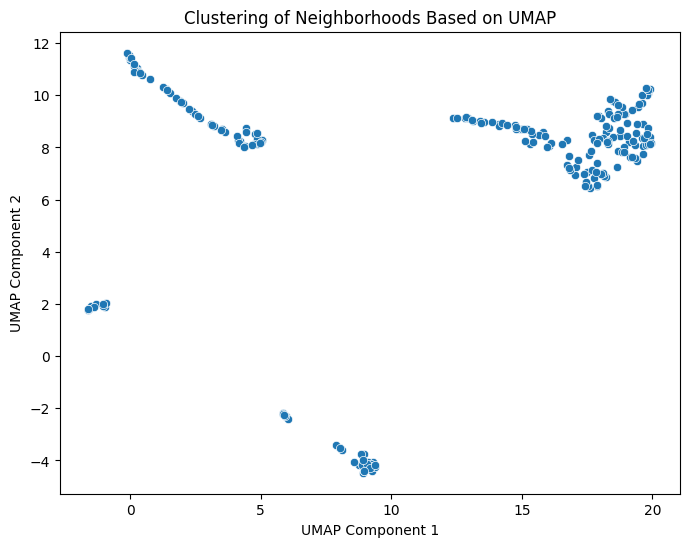

,UMAP1,UMAP2,Neighborhood
neighborhood,,,
Allerton,18.693953,7.858335,Allerton
Arden Heights,19.839802,10.096079,Arden Heights
Arrochar,19.035427,8.923841,Arrochar
Arverne,18.936611,9.273542,Arverne
Astoria,1.549651,10.104020,Astoria


In [25]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import umap

tmp = pivot_df_for_clustering
threshold = len(tmp) * 0.30 
amenity_counts = (tmp > 0).sum() 
amenities_to_keep = amenity_counts[amenity_counts >= threshold].index
pivot_df_for_clustering = tmp[amenities_to_keep]

# Apply UMAP for dimensionality reduction
umap_model = umap.UMAP(n_components=2, random_state=42,n_neighbors=10)
umap_result = umap_model.fit_transform(pivot_df_for_clustering)

# Create a DataFrame with UMAP results
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'], index=pivot_df_for_clustering.index)
umap_df['Neighborhood'] = umap_df.index

# Visualize the clusters using UMAP
plt.figure(figsize=(8, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', data=umap_df)
plt.title('Clustering of Neighborhoods Based on UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

umap_df.head()

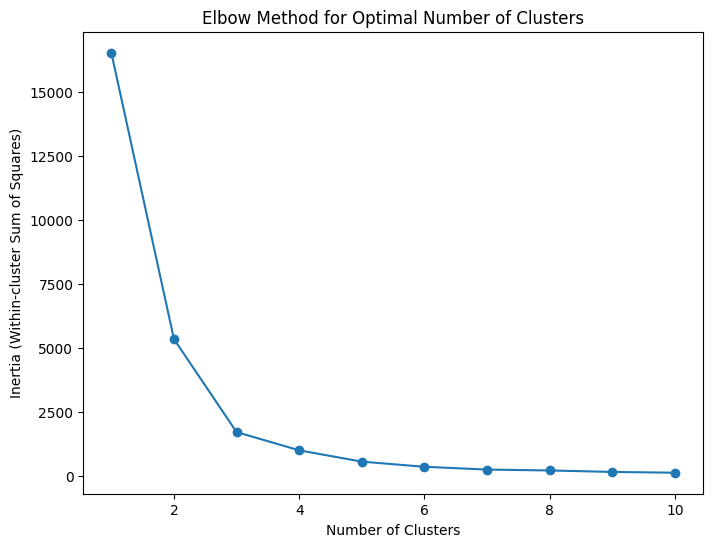

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(umap_df[['UMAP1', 'UMAP2']])
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.show()


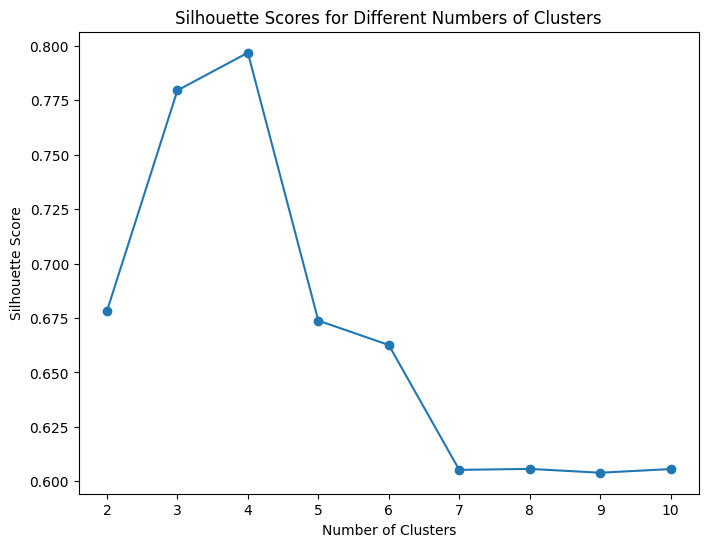

In [27]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(umap_df[['UMAP1', 'UMAP2']])
    sil_score = silhouette_score(umap_df[['UMAP1', 'UMAP2']], kmeans.labels_)
    sil_scores.append(sil_score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


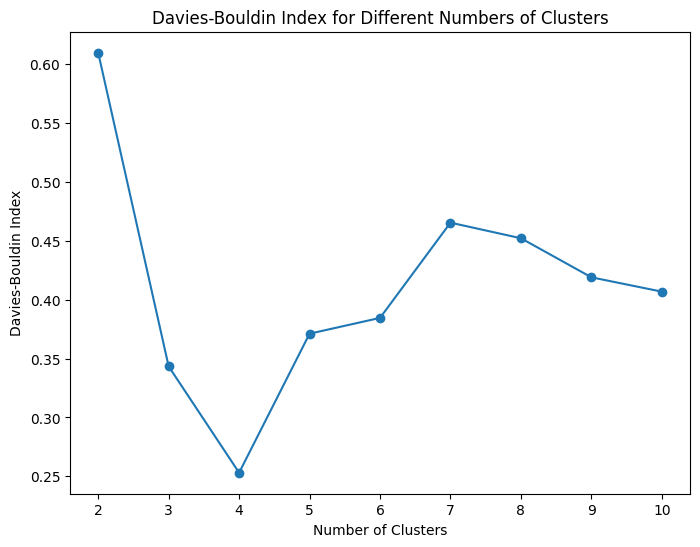

In [28]:
from sklearn.metrics import davies_bouldin_score

db_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(umap_df[['UMAP1', 'UMAP2']])
    db_score = davies_bouldin_score(umap_df[['UMAP1', 'UMAP2']], kmeans.labels_)
    db_scores.append(db_score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), db_scores, marker='o')
plt.title('Davies-Bouldin Index for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()


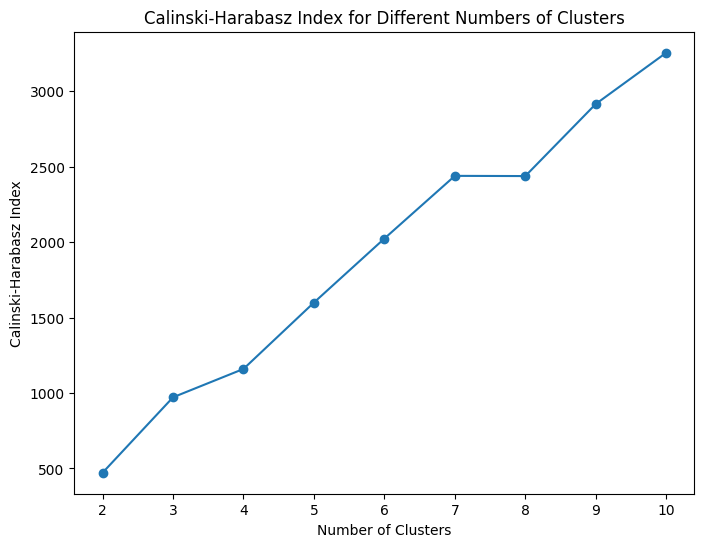

In [29]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(umap_df[['UMAP1', 'UMAP2']])
    ch_score = calinski_harabasz_score(umap_df[['UMAP1', 'UMAP2']], kmeans.labels_)
    ch_scores.append(ch_score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), ch_scores, marker='o')
plt.title('Calinski-Harabasz Index for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Calinski-Harabasz Index')
plt.show()


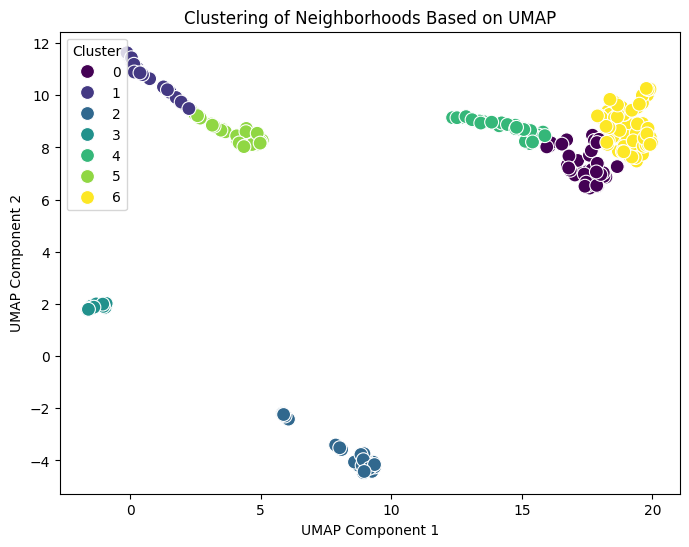

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=42)
umap_df['Cluster'] = kmeans.fit_predict(umap_df[['UMAP1', 'UMAP2']])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', data=umap_df, palette='viridis', s=100)
plt.title('Clustering of Neighborhoods Based on UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

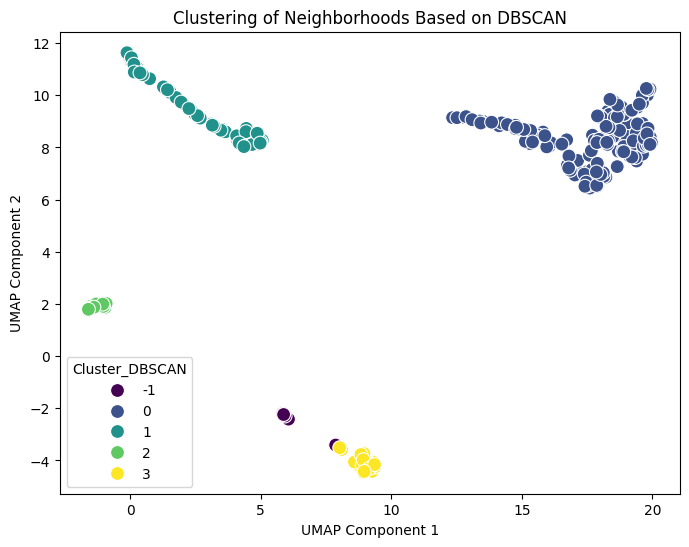

In [31]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.9, min_samples=10) 
umap_df['Cluster_DBSCAN'] = dbscan.fit_predict(umap_df[['UMAP1', 'UMAP2']])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster_DBSCAN', data=umap_df, palette='viridis', s=100)
plt.title('Clustering of Neighborhoods Based on DBSCAN')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()


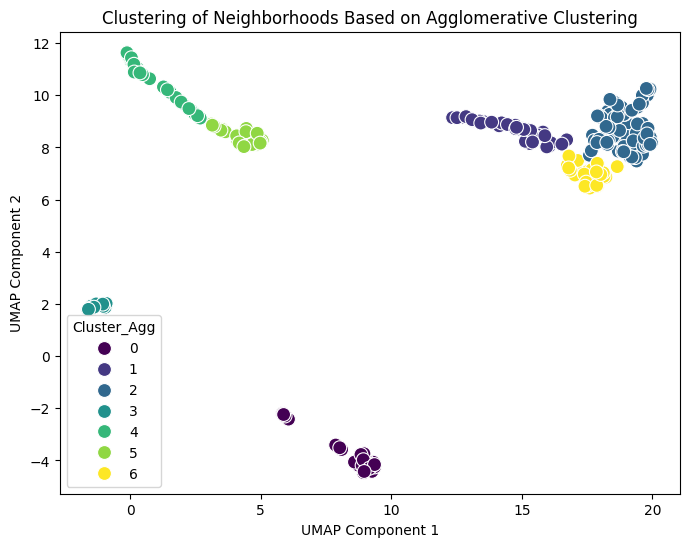

In [32]:
from sklearn.cluster import AgglomerativeClustering

agg_clust = AgglomerativeClustering(n_clusters=7)
umap_df['Cluster_Agg'] = agg_clust.fit_predict(umap_df[['UMAP1', 'UMAP2']])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster_Agg', data=umap_df, palette='viridis', s=100)
plt.title('Clustering of Neighborhoods Based on Agglomerative Clustering')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()


C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


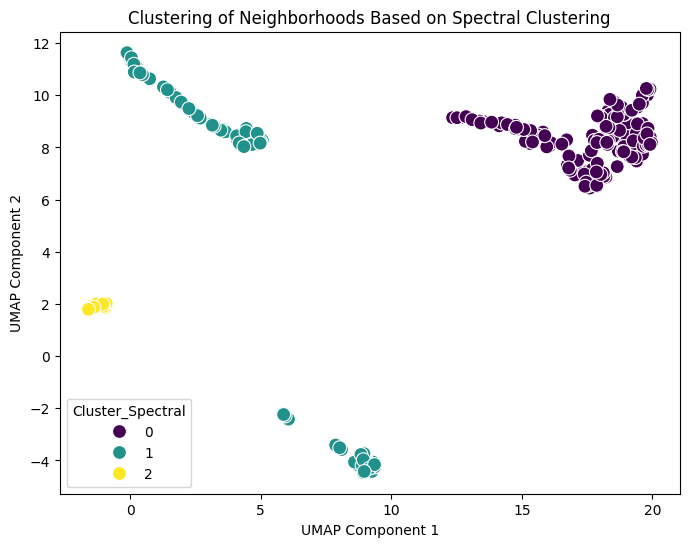

In [33]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
umap_df['Cluster_Spectral'] = spectral.fit_predict(umap_df[['UMAP1', 'UMAP2']])

plt.figure(figsize=(8, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster_Spectral', data=umap_df, palette='viridis', s=100)
plt.title('Clustering of Neighborhoods Based on Spectral Clustering')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()


In [34]:
listings = pd.read_csv("..\\Data\\Airbnb_NY_City_04112024\\listings.csv")
booking = pd.read_csv("listing_booking_info.csv")

listings_merged = pd.merge(listings,booking,left_on='id', right_on='listing_id')
listings_merged = listings_merged[(listings_merged['booking_ratio'] <= 0.70)]
listings_merged = listings_merged[(listings_merged['booking_ratio'] >= 0.30)]
listings_merged.head()



,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,Unnamed: 0,listing_id,total_days,unavailable_days,available_days,booking_ratio
1,6848,https://www.airbnb.com/rooms/6848,20241104040953,2024-11-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,https://www.airbnb.com/users/show/15991,Allen & Irina,2009-05-06,"New York, NY",We love to travel. When we travel we like to s...,within a few hours,100%,100%,t,https://a0.muscache.com/im/users/15991/profile...,https://a0.muscache.com/im/users/15991/profile...,Williamsburg,1.0,1.0,"['email', 'phone']",t,t,NaN,Williamsburg,Brooklyn,40.709350,-73.953420,Entire rental unit,Entire home/apt,3,1.0,1 bath,2.0,1.0,"[""Fire extinguisher"", ""Smoke alarm"", ""Stove"", ...",$83.00,30,120,30.0,30.0,120.0,120.0,30.0,120.0,NaN,t,0,15,15,185,2024-11-04,195,4,1,2009-05-25,2024-10-05,4.58,4.59,4.85,4.85,4.80,4.69,4.58,NaN,f,1,1,0,0,1.04,1,6848,365,180,185,0.493151
5,7097,https://www.airbnb.com/rooms/7097,20241104040953,2024-11-04,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,"Residential, village-like atmosphere. Lots of ...",https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,https://www.airbnb.com/users/show/17571,Jane,2009-05-17,"New York, NY","I appreciate visitors and know New York well, ...",within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/18480...,https://a0.muscache.com/im/pictures/user/18480...,Fort Greene,2.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,Fort Greene,Brooklyn,40.691940,-73.973890,Private room in guest suite,Private room,2,1.0,1 private bath,1.0,2.0,"[""Fire extinguisher"", ""Smoke alarm"", ""Private ...",$205.00,2,1125,1.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,1,6,32,215,2024-11-04,390,38,5,2010-01-16,2024-10-27,4.89,4.91,4.89,4.96,4.93,4.95,4.82,OSE-STRREG-0000008,t,2,0,2,0,2.16,5,7097,365,150,215,0.410959
7,8490,https://www.airbnb.com/rooms/8490,20241104040953,2024-11-04,city scrape,"Maison des Sirenes1,bohemian, luminous apartment",Soak up the modern and vintage charm<br />of t...,NaN,https://a0.muscache.com/pictures/1d0d9773-c829...,25183,https://www.airbnb.com/users/show/25183,Nathalie,2009-07-10,"New York, NY",I am French and have been living in Ny for 10...,within an hour,100%,NaN,f,https://a0.muscache.com/im/users/25183/profile...,https://a0.muscache.com/im/users/25183/profile...,Bedford-Stuyvesant,2.0,3.0,"['email', 'phone']",t,t,NaN,Bedford-Stuyvesant,Brooklyn,40.684556,-73.939634,Entire loft,Entire home/apt,5,1.0,1 bath,1.0,4.0,"[""Board games"", ""Private patio or balcony"", ""B...",$170.00,30,1125,30.0,30.0,1125.0,1125.0,

In [35]:

neighborhood_stats = listings_merged.groupby('neighbourhood_cleansed').agg(
    number_of_listings=('listing_id', 'count'),
    average_booking_ratio=('booking_ratio', 'median'),
    average_review_scores_rating=('review_scores_rating', 'median'),
    average_review_scores_accuracy=('review_scores_accuracy', 'median'),
    average_review_scores_cleanliness=('review_scores_cleanliness', 'median'),
    average_review_scores_checkin=('review_scores_checkin', 'median'),
    average_review_scores_communication=('review_scores_communication', 'median'),
    average_review_scores_location=('review_scores_location', 'median'),
    average_review_scores_value=('review_scores_value', 'median')
).reset_index()

neighborhood_stats.head()

,neighbourhood_cleansed,number_of_listings,average_booking_ratio,average_review_scores_rating,average_review_scores_accuracy,average_review_scores_cleanliness,average_review_scores_checkin,average_review_scores_communication,average_review_scores_location,average_review_scores_value
0,Allerton,9,0.506849,4.750,4.830,4.75,4.84,4.89,4.720,4.750
1,Arden Heights,2,0.419178,4.935,4.905,5.00,5.00,5.00,4.935,4.935
2,Arrochar,1,0.586301,4.530,4.650,4.80,4.70,4.78,4.580,4.630
3,Arverne,25,0.506849,4.930,4.890,4.89,4.97,4.97,4.720,4.790
4,Astoria,79,0.515068,4.930,4.940,4.89,4.96,4.97,4.890,4.835


In [36]:
import numpy as np
umap_df_reset = umap_df.reset_index()

merged_umap = pd.merge(umap_df_reset, neighborhood_stats, left_on='Neighborhood', right_on='neighbourhood_cleansed', how='left')

merged_umap = merged_umap.drop(columns=['neighbourhood_cleansed'])
merged_umap = merged_umap.dropna()

merged_umap = pd.merge(merged_umap, gdf[['neighbourhood', 'area_meters_squared']],left_on='Neighborhood',right_on='neighbourhood')

merged_umap['listings_per_sq_meter'] = merged_umap['number_of_listings']/merged_umap['area_meters_squared']
merged_umap['log_listings_per_sq_meter'] = np.log(merged_umap['listings_per_sq_meter'])
merged_umap['log_median_booking_ratio'] = np.log(merged_umap['average_booking_ratio'])


merged_umap


,neighborhood,UMAP1,UMAP2,Neighborhood,Cluster,Cluster_DBSCAN,Cluster_Agg,Cluster_Spectral,number_of_listings,average_booking_ratio,average_review_scores_rating,average_review_scores_accuracy,average_review_scores_cleanliness,average_review_scores_checkin,average_review_scores_communication,average_review_scores_location,average_review_scores_value,neighbourhood,area_meters_squared,listings_per_sq_meter,log_listings_per_sq_meter,log_median_booking_ratio
0,Allerton,18.693953,7.858335,Allerton,6,0,2,0,9.0,0.506849,4.750,4.830,4.750,4.840,4.890,4.720,4.750,Allerton,4.231216e+06,2.127048e-06,-13.060775,-0.679542
1,Arden Heights,19.839802,10.096079,Arden Heights,6,0,2,0,2.0,0.419178,4.935,4.905,5.000,5.000,5.000,4.935,4.935,Arden Heights,6.761099e+06,2.958099e-07,-15.033549,-0.869459
2,Arrochar,19.035427,8.923841,Arrochar,6,0,2,0,1.0,0.586301,4.530,4.650,4.800,4.700,4.780,4.580,4.630,Arrochar,3.584128e+06,2.790079e-07,-15.092026,-0.533921
3,Arverne,18.936611,9.273542,Arverne,6,0,2,0,25.0,0.506849,4.930,4.890,4.890,4.970,4.970,4.720,4.790,Arverne,3.430058e+06,7.288506e-06,-11.829212,-0.679542
4,Astoria,1.549651,10.104020,Astoria,1,1,4,1,79.0,0.515068,4.930,4.940,4.890,4.960,4.970,4.890,4.835,Astoria,8.193087e+06,9.642275e-06,-11.549353,-0.663455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Williamsburg,0.382913,10.862535,Williamsburg,1,1,4,1,261.0,0.509589,4.900,4.920,4.860,4.960,4.970,4.940,4.790,Williamsburg,1.361841e+07,1.916523e-05,-10.862413,-0.674151
196,Windsor Terrace,-1.382711,1.876029,Windsor Terrace,3,2,3,2,22.0,0.550685,4.895,4.920,4.930,4.925,4.930,4.945,4.795,Windsor Terrace,1.925477e+06,1.142574e-05,-11.379642,-0.596592
197,Woodhaven,17.853092,7.062185,Woodhaven,0,0,6,0,23.0,0.624658,4.790,4.850,4.820,4.970,4.950,4.740,4.750,Woodhaven,3.791449e+06,6.066283e-06,-12.012765,-0.470552
198,Woodlawn,16.791248,7.215446,Woodlawn,0,0,6,0,4.0,0.495890,4.935,5.000,4.900,5.000,5.000,5.000,4.900,Woodlawn,4.542699e+06,8.805339e-07,-13.942737,-0.701400


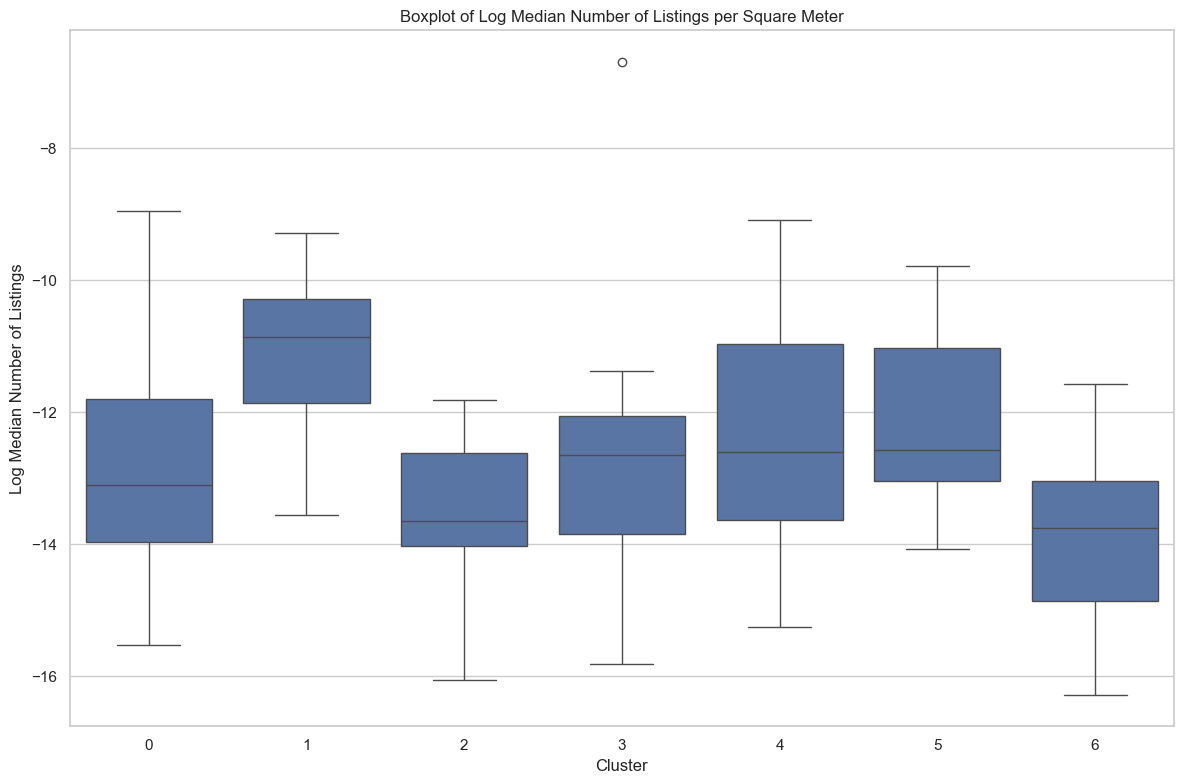

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

sns.boxplot(x='Cluster', y='log_listings_per_sq_meter', data=merged_umap)

plt.title('Boxplot of Log Median Number of Listings per Square Meter')
plt.xlabel('Cluster')
plt.ylabel('Log Median Number of Listings')

plt.tight_layout()
plt.show()


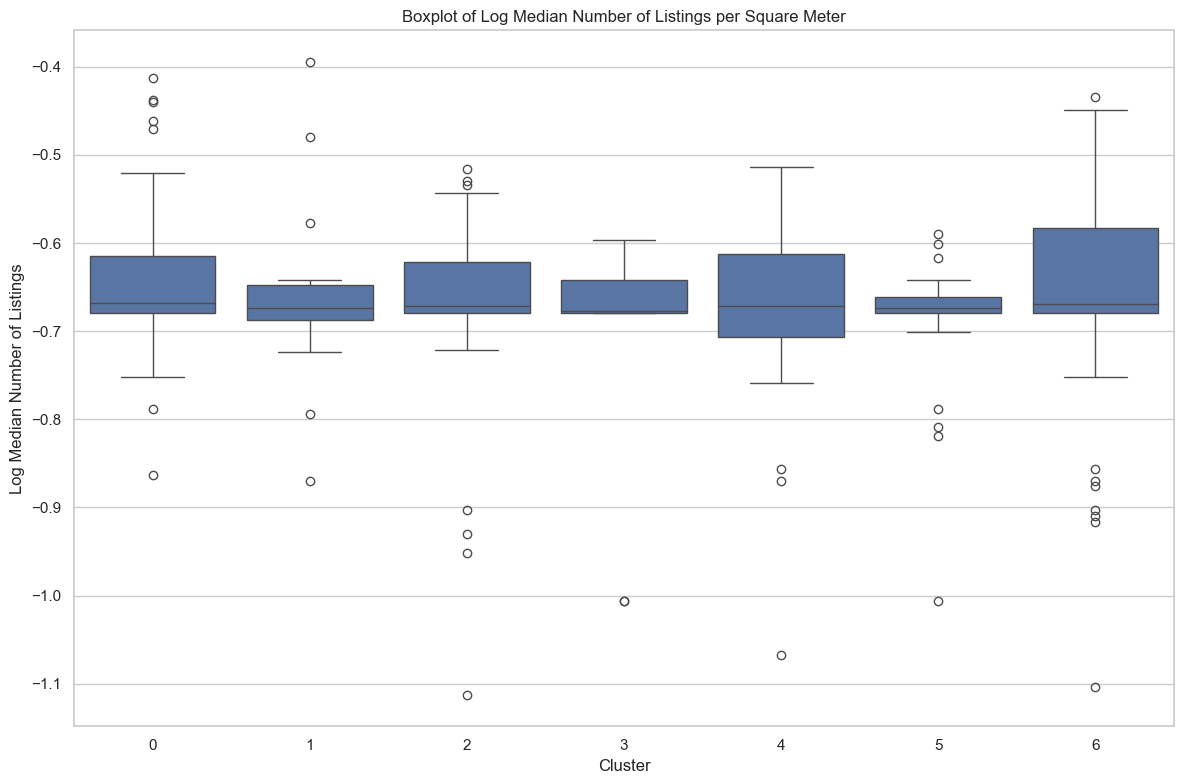

In [38]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

sns.boxplot(x='Cluster', y='log_median_booking_ratio', data=merged_umap)

plt.title('Boxplot of Log Median Number of Listings per Square Meter')
plt.xlabel('Cluster')
plt.ylabel('Log Median Number of Listings')

plt.tight_layout()
plt.show()

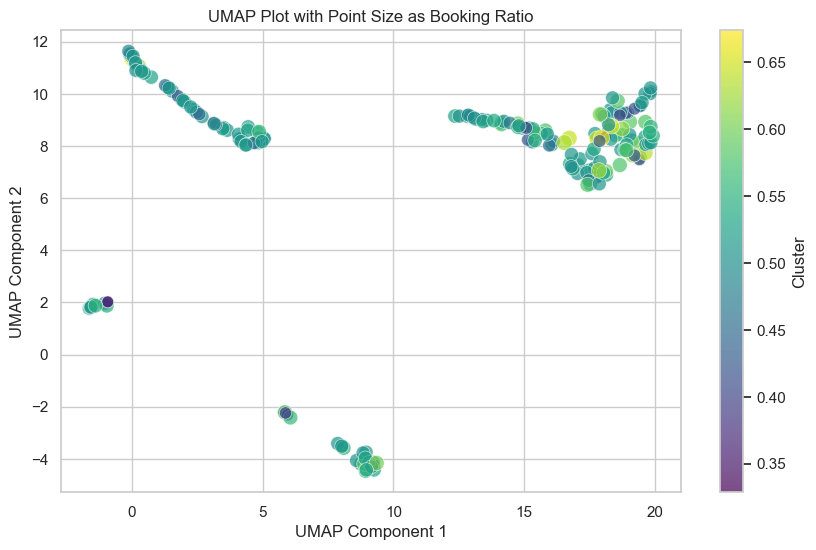

In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(merged_umap['UMAP1'], merged_umap['UMAP2'], 
            c=merged_umap['average_booking_ratio'], cmap='viridis', alpha=0.7, 
            s=merged_umap['average_booking_ratio']*200,
            edgecolors='w', linewidth=0.5)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("UMAP Plot with Point Size as Booking Ratio")
plt.colorbar(label='Cluster')

plt.show()


In [40]:
filtered_data = merged_umap[merged_umap['average_booking_ratio'] > 0.5]
cluster_counts = filtered_data.groupby('Cluster').size()

print(cluster_counts)

Cluster
0    27
1    20
2    21
3     7
4    23
5    22
6    39
dtype: int64


In [41]:
#pivot_df_for_clustering = pivot_df_for_clustering.drop(columns=["cluster"])

#pivot_df_for_clustering.reset_index(inplace=True)\

pivot_df_for_clustering = pivot_df_for_clustering.loc[:, (pivot_df_for_clustering != 0).any(axis=0)]

pivot_df_for_clustering.to_csv("factype_count_per_airbnb_neighborhood.csv",index=False)

print(pivot_df_for_clustering.head())


FACTYPE        COMMERCIAL GARAGE  COMMERCIAL GARAGE AND PARKING LOT  COMMERCIAL PARKING LOT  COMMUNITY PARK  JOINTLY OPERATED PLAYGROUND  MULTI-DISCIPL, PERF & NON-PERF  MULTI-DISCIPLINE, PERFORMING  ...  NEIGHBORHOOD PARK  PARKWAY  PLAYGROUND  PUBLIC LIBRARY  STATE HISTORIC PLACE  THEATER  TRIANGLE/PLAZA
neighborhood                                                                                                                                                                                            ...                                                                                                       
Allerton                       1                                  0                       1               0                            1                               0                             1  ...                  0        5           5               1                     2        0               1
Arden Heights                  0                                  0            